In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
files = [f'../data/raw/UNSW-NB15_{i}.csv' for i in range(1, 5)]
features = pd.read_csv('../data/raw/UNSW-NB15_features.csv', encoding='latin-1')

df = pd.concat(
    [pd.read_csv(f, header=None, low_memory=False) for f in files],
    ignore_index=True
)
df.columns = features['Name'].tolist()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2540047, 49)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0


Class counts:
Label
0    2218764
1     321283
Name: count, dtype: int64

Class percentages:
Label
0    87.35
1    12.65
Name: proportion, dtype: float64


C:\Users\dcphi\AppData\Local\Temp\ipykernel_27300\138343925.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Normal', 'Attack'], y=label_counts.values, palette=['steelblue', 'tomato'])


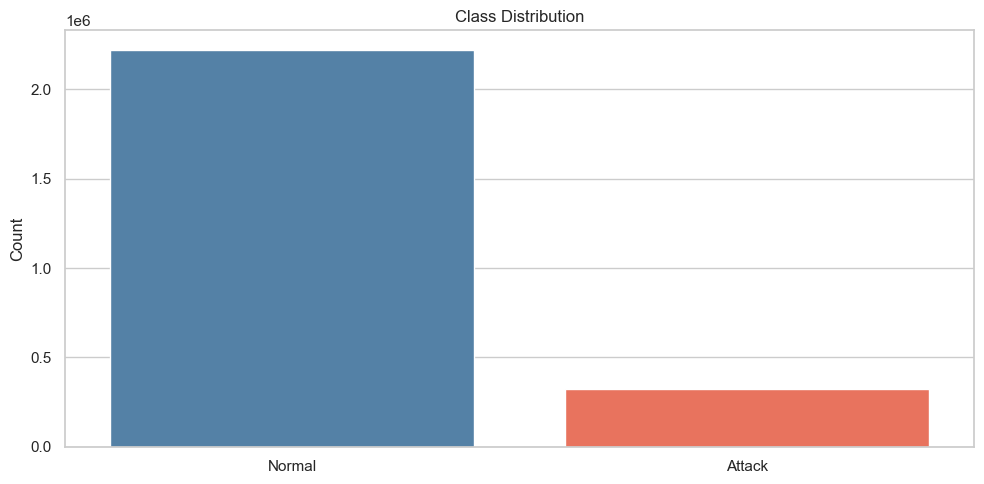

In [3]:
label_counts = df['Label'].value_counts()
label_pct = df['Label'].value_counts(normalize=True) * 100

print("Class counts:")
print(label_counts)
print("\nClass percentages:")
print(label_pct.round(2))

plt.figure()
sns.barplot(x=['Normal', 'Attack'], y=label_counts.values, palette=['steelblue', 'tomato'])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Columns with missing values: 3
attack_cat          2218764
is_ftp_login        1429879
ct_flw_http_mthd    1348145
dtype: int64


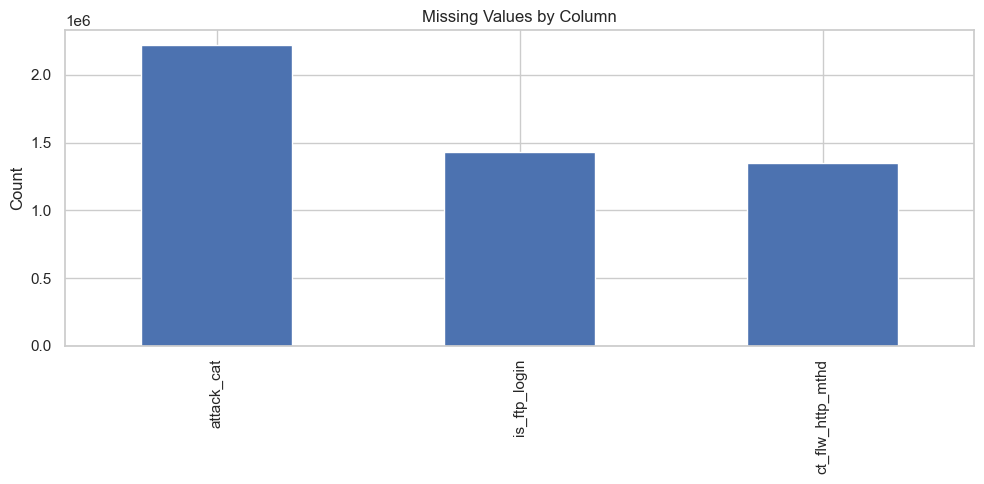

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f"Columns with missing values: {len(missing)}")
print(missing)

if len(missing) > 0:
    plt.figure()
    missing.plot(kind='bar')
    plt.title('Missing Values by Column')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

C:\Users\dcphi\AppData\Local\Temp\ipykernel_27300\2978552811.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attack_counts.values, y=attack_counts.index, palette='Reds_r')


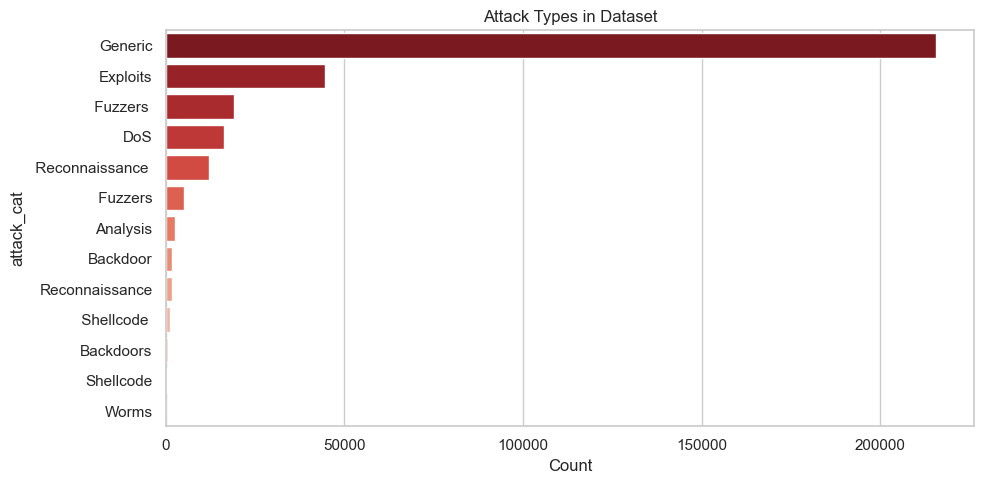

In [5]:
attack_counts = df[df['Label'] == 1]['attack_cat'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=attack_counts.values, y=attack_counts.index, palette='Reds_r')
plt.title('Attack Types in Dataset')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

Top features correlated with connection duration:
 Dintpkt        0.097152
Dpkts          0.089368
Spkts          0.088082
dloss          0.087713
dbytes         0.086971
Sintpkt        0.071668
Djit           0.048020
res_bdy_len    0.043873
sloss          0.041493
dmeansz        0.035822
Name: dur, dtype: float64


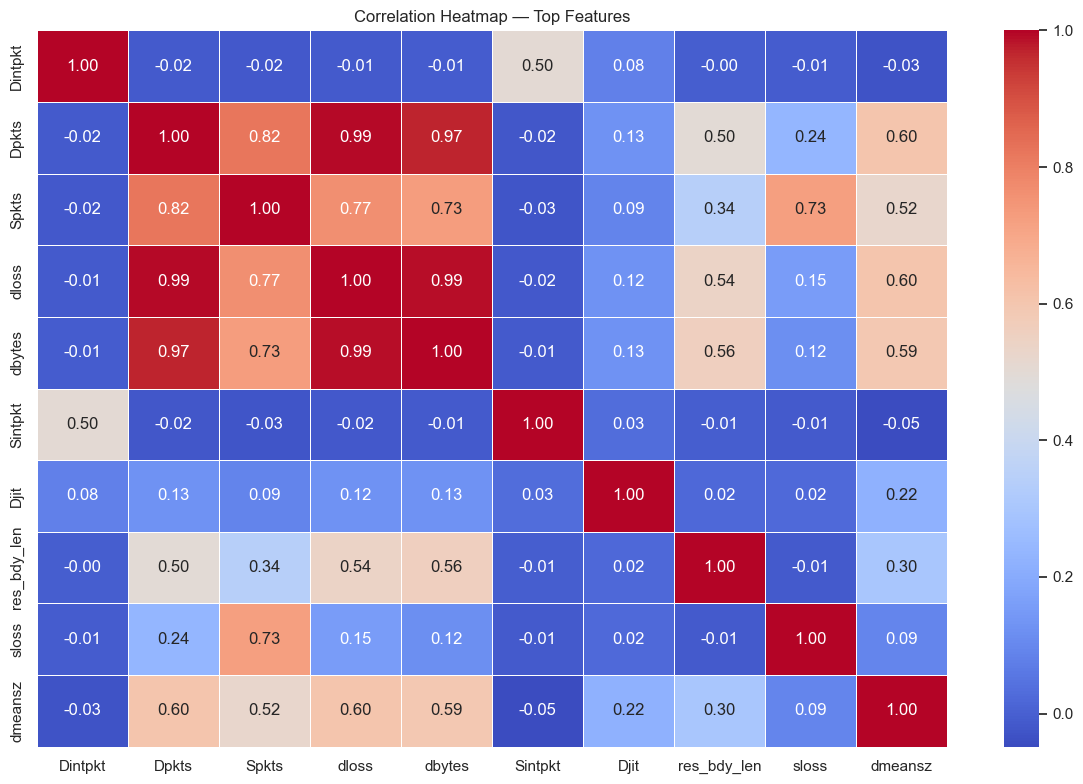

In [6]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['Label'])
corr = numeric_df.corr()

top_corr = corr['dur'].abs().sort_values(ascending=False).head(11)[1:]
print("Top features correlated with connection duration:\n", top_corr)

plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_df[top_corr.index].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5
)
plt.title('Correlation Heatmap — Top Features')
plt.tight_layout()
plt.show()

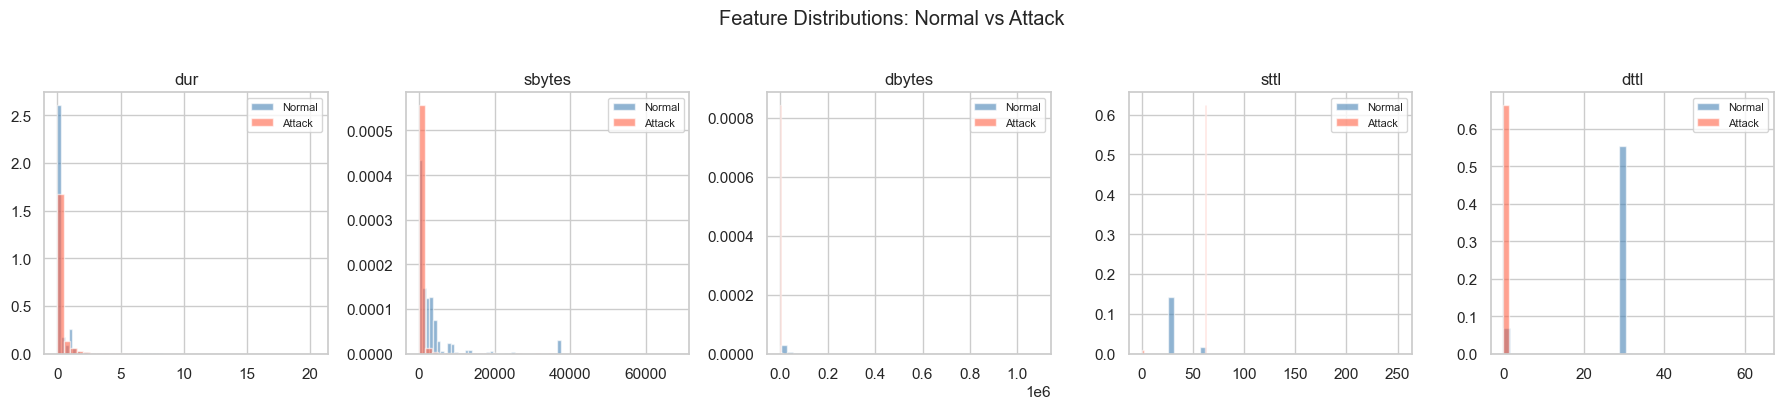

In [7]:
features_to_plot = ['dur', 'sbytes', 'dbytes', 'sttl', 'dttl']

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(18, 4))
for ax, feat in zip(axes, features_to_plot):
    for label, color, name in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'Attack')]:
        subset = df[df['Label'] == label][feat].dropna()
        subset = subset[subset < subset.quantile(0.99)]  # trim outliers for visibility
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Normal vs Attack', y=1.02)
plt.tight_layout()
plt.show()

## Key Findings

- The dataset is heavily imbalanced — ~87% normal traffic, ~13% attacks
- Nine distinct attack categories are present, with Generic and Exploits being most common
- Several features show clear distributional differences between normal and attack traffic
- Missing values are concentrated in a small number of columns and were handled by dropping high-null columns and filling remaining gaps with column medians
- These patterns justify the use of tree-based models (Random Forest, XGBoost) which can capture non-linear boundaries between classes